In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv("parking_classification.csv")

In [17]:
df = df.drop(columns=["date", "total_spaces", "free"]) # drop the columns we don't need

In [19]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(df,
                                        test_size=0.2,
                                        stratify=df["occupied"],
                                        random_state=42)

train_features = train_data.drop(columns=["occupied"])
train_target = train_data["occupied"]

test_features = test_data.drop(columns=["occupied"])
test_target = test_data["occupied"]

In [20]:
train_features_numerical = train_features[["day_index"]] # numerical features

train_features_categorical = train_features[["day_of_week", "time_slot", "is_holiday", "spot_id"]] # categorical features

In [21]:
# Encoding and Scaling

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

col_tran = ColumnTransformer([
    ("numerical", StandardScaler(), train_features_numerical.columns),
    ("categorical", OneHotEncoder(), train_features_categorical.columns)
])

# SGD Classifier

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier

sgd_model = Pipeline([
    ("transformer", col_tran),
    ("classifier", SGDClassifier(random_state=42))
])

In [27]:
sgd_model.fit(train_features, train_target)

,steps,"[('transformer', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [29]:
# Train features prediction:
train_features_predict = sgd_model.predict(train_features)

Train Confusion Matrix:
 [[3931 3468]
 [2099 4902]]




Text(0.5, 1.0, 'Confusion Matrix Heatmap')

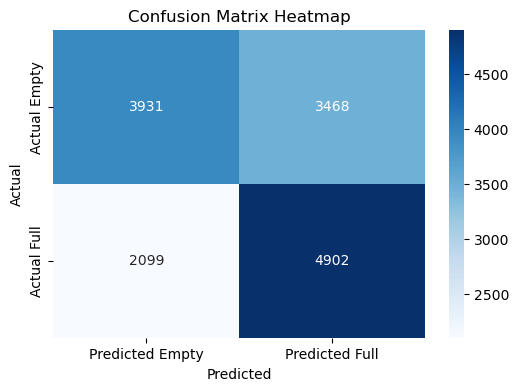

In [32]:
# Evaluate

from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score

# confusion matrix
print("Train Confusion Matrix:\n", confusion_matrix(train_target, train_features_predict))

##
print("\n")
##

# Confusion Matrix Heat-Map
cm = confusion_matrix(train_target, train_features_predict)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Predicted Empty", "Predicted Full"], yticklabels=["Actual Empty", "Actual Full"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")

In [34]:
# Accuracy
print("Train Accuracy:", accuracy_score(train_target, train_features_predict))

# Recall
print("Train Recall score:", recall_score(train_target, train_features_predict))

# Precision
print("Train Precision score:", precision_score(train_target, train_features_predict))

# f1-score
print("Train F1-score:", f1_score(train_target, train_features_predict))

Train Accuracy: 0.6134027777777777
Train Recall score: 0.7001856877588916
Train Precision score: 0.5856630824372759
Train F1-score: 0.6378244746600742


In [53]:
# Test features predistion:
test_features_predict = sgd_model.predict(test_features)

Test Confusion Matrix:
 [[1010  840]
 [ 560 1190]]




Text(0.5, 1.0, 'Confusion Matrix Heatmap')

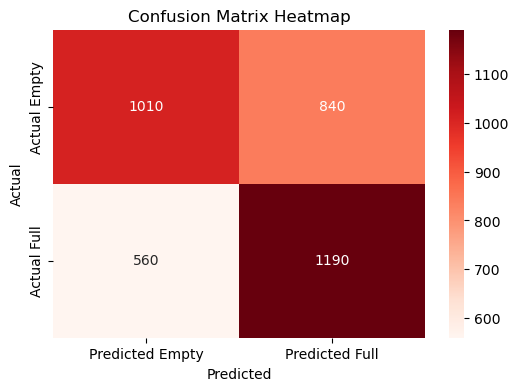

In [116]:
# Test prediction evaluate

# confusion matrix
print("Test Confusion Matrix:\n", confusion_matrix(test_target, test_features_predict))
##
print("\n")
##
cm_test = confusion_matrix(test_target, test_features_predict)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Reds", xticklabels=["Predicted Empty", "Predicted Full"], yticklabels=["Actual Empty", "Actual Full"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")

In [55]:
# Accuracy
print("Test Accuracy:", accuracy_score(test_target, test_features_predict))

# Recall
print("Test Recall score:", recall_score(test_target, test_features_predict))

# Precision
print("Test Precision score:", precision_score(test_target, test_features_predict))

# f1-score
print("Test F1-score:", f1_score(test_target, test_features_predict))

Test Accuracy: 0.6111111111111112
Test Recall score: 0.68
Test Precision score: 0.5862068965517241
Test F1-score: 0.6296296296296297


# Decision Tree Classifier

In [222]:
# Since the dataset is already prepared above, we can use it for other models.

In [154]:
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline([
    ("preprocessing", col_tran),
    ("classifier", DecisionTreeClassifier(random_state=40))
])

In [156]:
dt_pipeline.fit(train_features, train_target)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [157]:
dt_train_predict = dt_pipeline.predict(train_features)

Train Confusion Matrix:
 [[7399    0]
 [   0 7001]]




Text(0.5, 1.0, 'Confusion Matrix Heatmap')

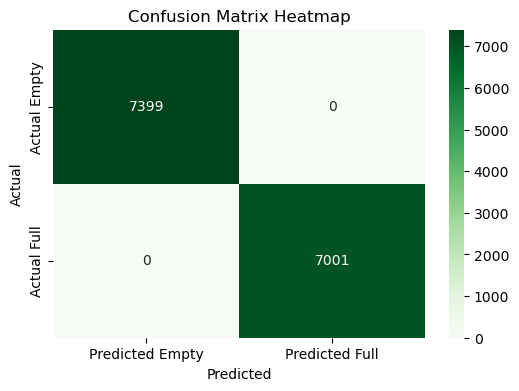

In [158]:
# confusion matrix
print("Train Confusion Matrix:\n", confusion_matrix(train_target, dt_train_predict))


dt_cm_train = confusion_matrix(train_target, dt_train_predict)

##
print("\n")
##
plt.figure(figsize=(6, 4))
sns.heatmap(dt_cm_train, annot=True, fmt="d", cmap="Greens", xticklabels=["Predicted Empty", "Predicted Full"], yticklabels=["Actual Empty", "Actual Full"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")

In [159]:
print("Train Accuracy: ", accuracy_score(train_target, dt_train_predict))
print("Train Precision score: ", precision_score(train_target, dt_train_predict))
print("Train Recall score: ", recall_score(train_target, dt_train_predict))
print("Train F1-score: ", f1_score(train_target, dt_train_predict))

Train Accuracy:  1.0
Train Precision score:  1.0
Train Recall score:  1.0
Train F1-score:  1.0


In [160]:
# Test features prediction
dt_test_predict = dt_pipeline.predict(test_features)

Test Confusion Matrix:
 [[965 885]
 [820 930]]




Text(0.5, 1.0, 'Confusion Matrix Heatmap')

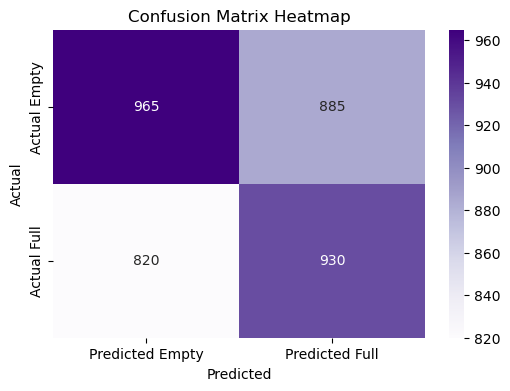

In [161]:
# confusion matrix
print("Test Confusion Matrix:\n", confusion_matrix(test_target, dt_test_predict))


dt_cm_test = confusion_matrix(test_target, dt_test_predict)

##
print("\n")
##

plt.figure(figsize=(6, 4))
sns.heatmap(dt_cm_test, annot=True, fmt="d", cmap="Purples", xticklabels=["Predicted Empty", "Predicted Full"], yticklabels=["Actual Empty", "Actual Full"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")

In [162]:
print("Test Accuarcy: ", accuracy_score(test_target, dt_test_predict))
print("Test Precision score: ", precision_score(test_target, dt_test_predict))
print("Test Recall score: ", recall_score(test_target, dt_test_predict))
print("Test F1-score: ", f1_score(test_target, dt_test_predict))

Test Accuarcy:  0.5263888888888889
Test Precision score:  0.512396694214876
Test Recall score:  0.5314285714285715
Test F1-score:  0.5217391304347826


In [224]:
## !!!
# ----------
# Train Accuracy:  1.0
# Test Accuarcy:  0.5302777777777777
# ----------
# This is obviously overfitting!
# ----------

In [226]:
# We use cross-validation to confirm that overfitting is occurring.

In [176]:
from sklearn.model_selection import cross_val_score

dt_train_cv = cross_val_score(dt_pipeline, train_features, train_target, cv=5, scoring="accuracy")

In [184]:
print("Cross_val Accuracy:", dt_train_cv)
print("Mean of cross val scores: ", np.mean(dt_train_cv))

Cross_val Accuracy: [0.55       0.55243056 0.54513889 0.52916667 0.54861111]
Mean of cross val scores:  0.5450694444444444


In [228]:
# As we can see, the mean CV accuracy (0.545) is much lower than the train accuracy.
# This confirms that the model is overfitting.
# What can we do to fix this? Perform hyperparameter tuning.

In [190]:
# Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

# Parameters
param_grid = {
    "classifier__max_depth" : [3, 5, 7, 10, 15, None],
    "classifier__min_samples_leaf" :  [1, 2, 4, 6, 8],
    "classifier__criterion": ["gini", "entropy"], 
  
}

# Grid Search

dt_gs = GridSearchCV(
                    dt_pipeline,
                    param_grid=param_grid,
                    cv=5,
                    scoring="f1")

In [192]:
dt_gs.fit(train_features, train_target)

,estimator,Pipeline(step...m_state=40))])
,param_grid,"{'classifier__criterion': ['gini', 'entropy'], 'classifier__max_depth': [3, 5, ...], 'classifier__min_samples_leaf': [1, 2, ...]}"
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('numerical', ...), ('categorical', ...)]"


In [230]:
# This is optional, but we can also check the best parameters.
print("Best Params: ", dt_gs.best_params_)

Best Params:  {'classifier__criterion': 'entropy', 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 2}


In [260]:
# Best model with reduced overfitting:
dt_best_model = dt_gs.best_estimator_

In [262]:
dt_train_best_predict = dt_best_model.predict(train_features)

In [264]:
# Now let's evaluate on the test set:

print("Train new confusion matrix: \n", confusion_matrix(train_target, dt_train_best_predict))

Train new confusion matrix: 
 [[2177 5222]
 [ 780 6221]]


In [266]:
print("Train best Accuracy: ", accuracy_score(train_target, dt_train_best_predict))
print("Train best Recall score: ", recall_score(train_target, dt_train_best_predict))
print("Train best Precision score: ", precision_score(train_target, dt_train_best_predict))
print("Train best F1-score: ", f1_score(train_target, dt_train_best_predict))

Train best Accuracy:  0.5831944444444445
Train best Recall score:  0.8885873446650479
Train best Precision score:  0.5436511404352006
Train best F1-score:  0.6745825200607244


In [268]:
# And for test data:
dt_test_best_model = best_model.predict(test_features)

In [270]:
print("Test new confusion matrix: \n", confusion_matrix(test_target, dt_test_best_model))

Test new confusion matrix: 
 [[ 524 1326]
 [ 219 1531]]


In [271]:
print("Test best Accuracy: ", accuracy_score(test_target, dt_test_best_model))
print("Test best Recall score: ", recall_score(test_target, dt_test_best_model))
print("Test best Precision score: ", precision_score(test_target, dt_test_best_model))
print("Test best F1-score: ", f1_score(test_target, dt_test_best_model))

Test best Accuracy:  0.5708333333333333
Test best Recall score:  0.8748571428571429
Test best Precision score:  0.535876793839692
Test best F1-score:  0.6646407640546994


In [299]:
## To save models:

# import joblib

## Decision Tree model:
# joblib.dump(best_model, "decision_tree_model.pkl")

## SGD Classifier model:
# joblib.dump(sgd_model, "sgd_best.pkl")

In [301]:
## Load model and predict:

# dt_loaded = joblib.load("decision_tree_model.pkl")
# y_pred = dt_loaded.predict(test_features)